In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel("../data/Superstore-final.xlsx")

print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [30]:
customer_count = df['Customer Name'].value_counts()

repeated = (customer_count > 1).sum()
non_repeated = (customer_count == 1).sum()

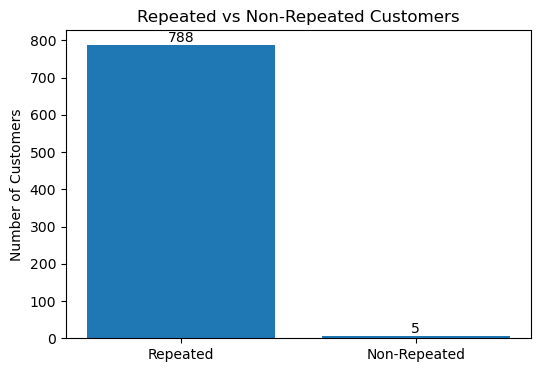

In [31]:
import matplotlib.pyplot as plt

labels = ['Repeated', 'Non-Repeated']
values = [repeated, non_repeated]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
# Show exact count on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )
plt.title('Repeated vs Non-Repeated Customers')
plt.ylabel('Number of Customers')

plt.show()

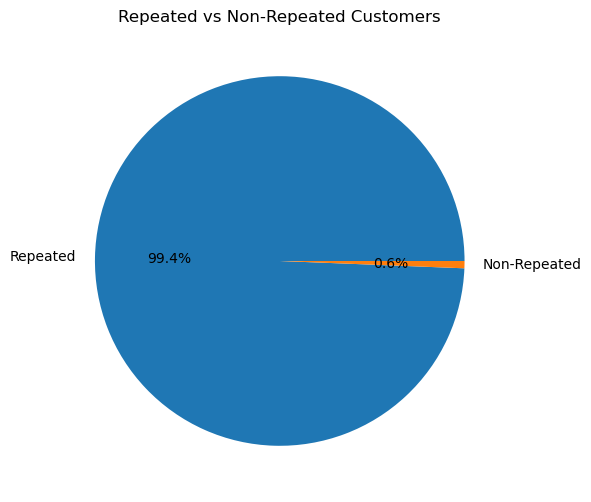

In [32]:
labels = ['Repeated', 'Non-Repeated']
values = [repeated, non_repeated]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Repeated vs Non-Repeated Customers')

plt.show()

In [44]:
order_count = df['Order ID'].value_counts()

order_count

Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
US-2015-126977    10
                  ..
CA-2014-110422     1
CA-2016-125794     1
CA-2017-163566     1
US-2015-151435     1
CA-2016-130225     1
Name: count, Length: 5009, dtype: int64

In [37]:
Total_orders=len(df['Order ID'])
Total_orders

9994

In [45]:
multiple_items = (order_count > 1).sum()
single_items = (order_count == 1).sum()

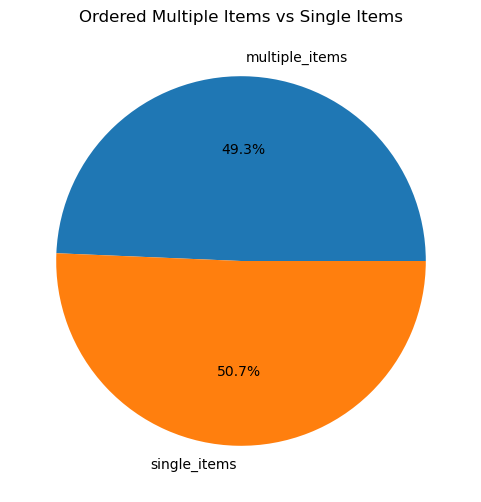

In [48]:
labels = ['multiple_items', 'single_items']
values = [multiple_items, single_items]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Ordered Multiple Items vs Single Items')

plt.show()

In [51]:
customer_product = df.groupby(
    ['Customer Name', 'Product Name']
).size().reset_index(name='Order_Count')

reordered_product = customer_product[
    customer_product['Order_Count'] > 1
]
# Customer-Product pairs ordered exactly once
single_order = customer_product[customer_product['Order_Count'] == 1]

customer_reordered_count = len(reordered)
customer_single_order_count = len(single_order)

print("Reordered Products:", customer_reordered_count)
print("Single Order Products:", customer_single_order_count)

Reordered Products: 53
Single Order Products: 9888


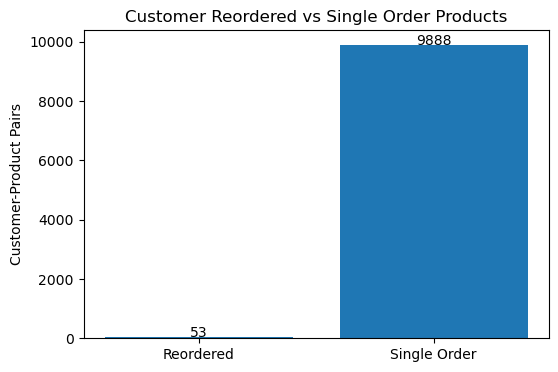

In [54]:
import matplotlib.pyplot as plt

labels = ['Reordered', 'Single Order']
values = [customer_reordered_count, customer_single_order_count]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

# Show exact counts on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center'
    )

plt.title('Customer Reordered vs Single Order Products')
plt.ylabel('Customer-Product Pairs')
plt.show()

In [61]:
V=df['Product Name'].nunique()
V

1850

In [60]:
V=len(df['Product Name'])
V

9994

In [64]:
product_count = df['Product Name'].value_counts()

unique_products = len(product_count)

reordered_products = (product_count > 1).sum()

single_order_products = (product_count == 1).sum()

print("Unique Products:", unique_products)
print("Reordered Products:", reordered_products)
print("Single Order Products:", single_order_products)

Unique Products: 1850
Reordered Products: 1759
Single Order Products: 91


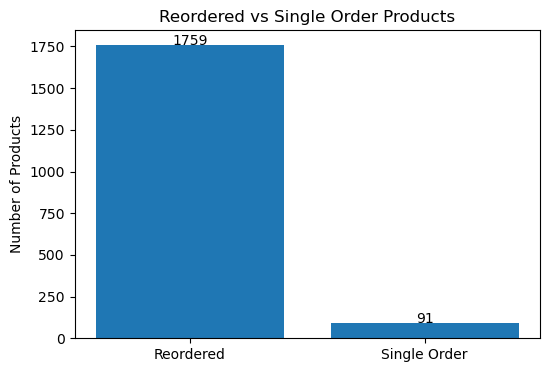

In [65]:
import matplotlib.pyplot as plt

labels = ['Reordered', 'Single Order']
values = [reordered_products, single_order_products]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values)

# Show counts on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center'
    )

plt.title('Reordered vs Single Order Products')
plt.ylabel('Number of Products')

plt.show()



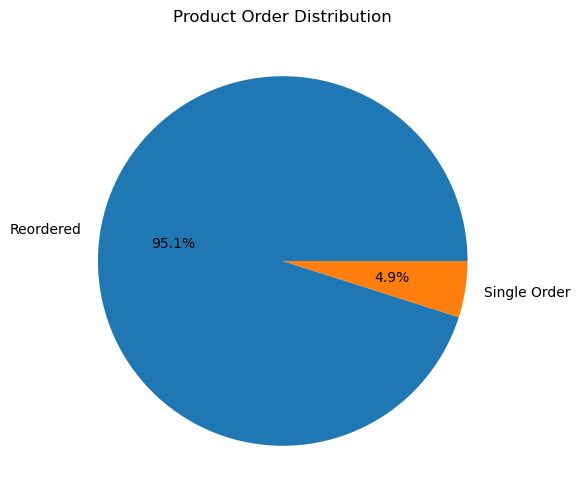

In [66]:
plt.figure(figsize=(6,6))

plt.pie(
    [reordered_products, single_order_products],
    labels=['Reordered', 'Single Order'],
    autopct='%1.1f%%'
)

plt.title('Product Order Distribution')

plt.show()

In [62]:
top_products = df['Product Name'].value_counts().head(10)

print(top_products)

Product Name
Staple envelope                               48
Staples                                       46
Easy-staple paper                             46
Avery Non-Stick Binders                       20
Staples in misc. colors                       19
KI Adjustable-Height Table                    18
Staple remover                                18
Storex Dura Pro Binders                       17
Staple-based wall hangings                    16
Situations Contoured Folding Chairs, 4/Set    15
Name: count, dtype: int64


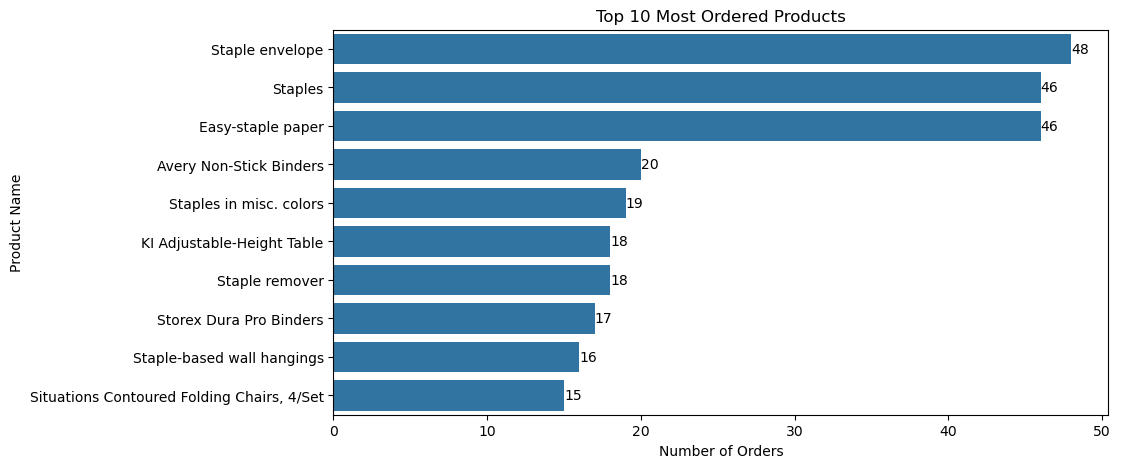

In [63]:
top_products = df['Product Name'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_products.values,
    y=top_products.index
)

# Show exact counts
for i, value in enumerate(top_products.values):
    ax.text(
        value,
        i,
        str(value),
        va='center'
    )

plt.title('Top 10 Most Ordered Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product Name')

plt.show()